# Window comparison: rectangular, hull, and custom

Three-way comparison of the observation windows across all strips:

1. **Visual overlay** â€” transcript scatter with all three window types overlaid
2. **Area comparison table** â€” areas and percentages relative to the bounding box
3. **L(r) comparison â€” positive control** (KRT8 \u00d7 KRT18)
4. **L(r) comparison â€” negative control** (MALAT1 \u00d7 KRT18)

**Prerequisites:**
- `02c_fov_review_and_expansion.ipynb` â€” expanded noise-flagged parquet
- `09a_unified_window_api.ipynb` â€” unified analysis functions (loaded via `%run`)
- `09b_custom_window_drawing.ipynb` â€” custom window JSON files per strip

**Methodological note on envelopes:** Each window type runs with its own
independent permutation envelope (99 label permutations under that window's
geometry). The envelopes are not directly comparable in absolute terms, but
each is internally self-consistent. The parameter `INDEPENDENT_ENVELOPES = True`
controls this; set to `False` to use the hull envelope as a shared reference
for all three curves.

## Setup

In [1]:
%run 09a_unified_window_api.ipynb

c:\Users\Harry\Desktop\NoSegs_Project\cosmx-pointpattern\.venv\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


rect window: (np.float64(0.33651938897161227), np.float64(999.6873091039064), np.float64(16.249489684368122), np.float64(2991.1905552060275))
hull window: Polygon, area=2852459 px²
Dispatch check passed.
Total transcripts loaded: 702,873
After noise removal:      649,637 (92.4% retained)
FOVs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Strips: ['strip_1', 'strip_2', 'strip_3']


In [2]:
X_COL = "x_global_px"
Y_COL = "y_global_px"

import os
from matplotlib.patches import Rectangle as MplRectangle

INDEPENDENT_ENVELOPES = True   # each window type gets its own permutation envelope

CUSTOM_PATHS = {
    'strip_1': '../data/processed/custom_window_strip_1.json',
    'strip_2': '../data/processed/custom_window_strip_2.json',
    'strip_3': '../data/processed/custom_window_strip_3.json',
}

# Check custom window files exist
for strip, path in CUSTOM_PATHS.items():
    exists = os.path.exists(path)
    print(f'  {strip}: {path} â€” {"found" if exists else "MISSING â€” run 09b first"}')

  strip_1: ../data/processed/custom_window_strip_1.json â€” found
  strip_2: ../data/processed/custom_window_strip_2.json â€” found
  strip_3: ../data/processed/custom_window_strip_3.json â€” found


## Section 1: Visual window overlay

One panel per strip. Blue dashed = rectangular bounding box; red = convex hull;
green = custom polygon. Areas reported in the legend.

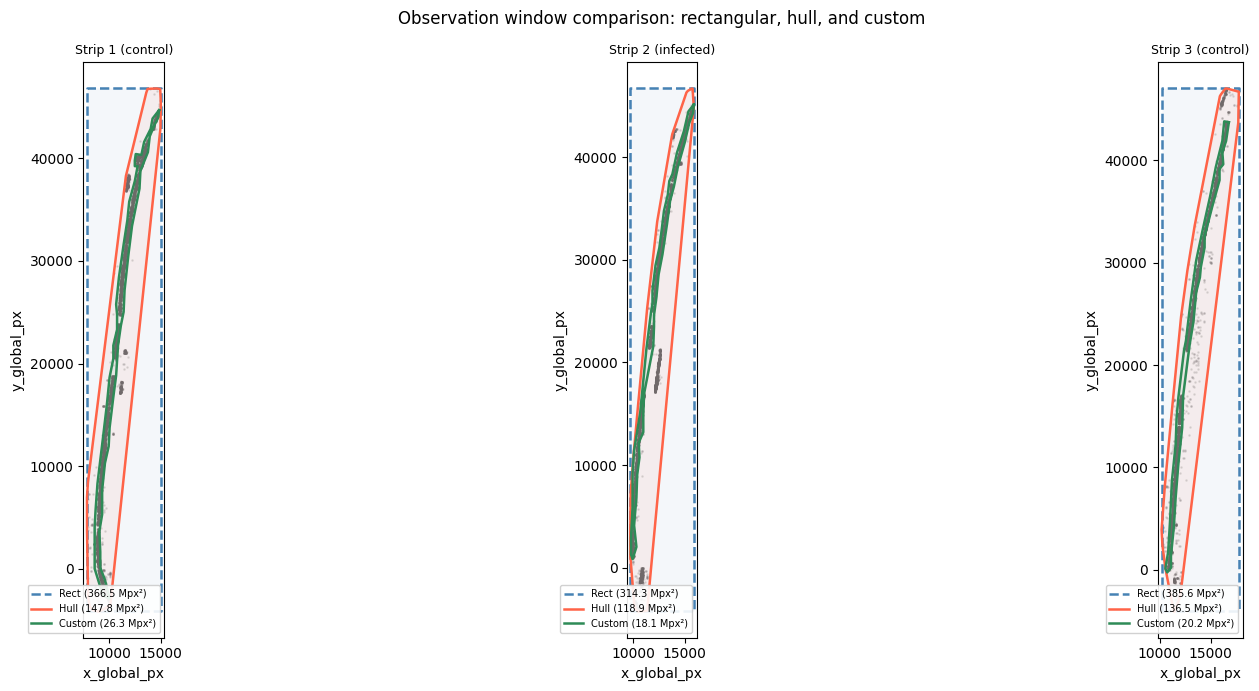

In [3]:
rng_vis = np.random.default_rng(0)
N_SCATTER = 10_000

fig, axes = plt.subplots(1, 3, figsize=(19, 7))

for ax, strip_name in zip(axes, STRIPS):
    strip_df = all_strips_clean[all_strips_clean['strip'] == strip_name]
    coords = strip_df[[X_COL, Y_COL]].values

    # Subsampled scatter
    n_show = min(len(coords), N_SCATTER)
    idx = rng_vis.choice(len(coords), n_show, replace=False)
    ax.scatter(coords[idx, 0], coords[idx, 1],
               s=1, alpha=0.15, c='dimgrey', rasterized=True)

    # --- Rectangular window ---
    w_rect = get_window(strip_df, window_type='rect')
    x_min, x_max, y_min, y_max = w_rect
    rect_area = (x_max - x_min) * (y_max - y_min)
    rect_patch = MplRectangle(
        (x_min, y_min), x_max - x_min, y_max - y_min,
        linewidth=1.8, edgecolor='steelblue', facecolor='steelblue',
        alpha=0.06, linestyle='--'
    )
    ax.add_patch(rect_patch)
    ax.plot([x_min, x_max, x_max, x_min, x_min],
            [y_min, y_min, y_max, y_max, y_min],
            color='steelblue', lw=1.8, linestyle='--',
            label=f'Rect ({rect_area/1e6:.1f} Mpx\u00b2)')

    # --- Convex hull ---
    w_hull = get_window(strip_df, window_type='hull')
    hx, hy = w_hull.exterior.xy
    ax.fill(hx, hy, color='tomato', alpha=0.07)
    ax.plot(hx, hy, color='tomato', lw=1.8,
            label=f'Hull ({w_hull.area/1e6:.1f} Mpx\u00b2)')

    # --- Custom polygon ---
    custom_path = CUSTOM_PATHS[strip_name]
    if os.path.exists(custom_path):
        w_custom = get_window(strip_df, window_type='custom', custom_path=custom_path)
        cx, cy = w_custom.exterior.xy
        ax.fill(cx, cy, color='seagreen', alpha=0.07)
        ax.plot(cx, cy, color='seagreen', lw=1.8,
                label=f'Custom ({w_custom.area/1e6:.1f} Mpx\u00b2)')
    else:
        ax.text(0.5, 0.5, 'Custom window\nnot yet drawn\n(run 09b)',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=9, color='seagreen')

    ax.set_title(STRIP_LABELS[strip_name], fontsize=9)
    ax.set_xlabel('x_global_px')
    ax.set_ylabel('y_global_px')
    ax.set_aspect('equal')
    ax.legend(fontsize=7, loc='lower right', markerscale=3, framealpha=0.9)

fig.suptitle('Observation window comparison: rectangular, hull, and custom', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/09c_window_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 2: Area comparison table

In [4]:
area_records = []
for strip_name in STRIPS:
    strip_df = all_strips_clean[all_strips_clean['strip'] == strip_name]

    w_rect   = get_window(strip_df, window_type='rect')
    x_min, x_max, y_min, y_max = w_rect
    rect_area = (x_max - x_min) * (y_max - y_min)

    w_hull   = get_window(strip_df, window_type='hull')
    hull_area = w_hull.area

    custom_path = CUSTOM_PATHS[strip_name]
    if os.path.exists(custom_path):
        w_custom     = get_window(strip_df, window_type='custom', custom_path=custom_path)
        custom_area  = w_custom.area
        custom_pct   = round(100 * custom_area / rect_area, 1)
    else:
        custom_area  = float('nan')
        custom_pct   = float('nan')

    area_records.append({
        'strip':         strip_name,
        'rect_Mpx2':     round(rect_area / 1e6, 2),
        'hull_Mpx2':     round(hull_area / 1e6, 2),
        'hull_%_rect':   round(100 * hull_area / rect_area, 1),
        'custom_Mpx2':   round(custom_area / 1e6, 2) if not np.isnan(custom_area) else 'n/a',
        'custom_%_rect': custom_pct,
    })

area_df = pd.DataFrame(area_records).set_index('strip')
print('Window area comparison:')
print(area_df.to_string())

area_df.to_csv('../results/figures/09c_window_areas.csv')
print('\nSaved: results/figures/09c_window_areas.csv')

Window area comparison:
         rect_Mpx2  hull_Mpx2  hull_%_rect  custom_Mpx2  custom_%_rect
strip                                                                 
strip_1     366.52     147.77         40.3        26.32            7.2
strip_2     314.28     118.92         37.8        18.10            5.8
strip_3     385.59     136.45         35.4        20.25            5.3

Saved: results/figures/09c_window_areas.csv


## Section 3: L(r) comparison â€” KRT8 x KRT18 (positive control)

Runs `run_pair_analysis` for each of the three window types per strip.
If `INDEPENDENT_ENVELOPES = True`, each window type gets its own permutation
envelope. If `False`, the hull envelope is shared across all three curves.

In [5]:
GENE_A = 'KRT8'
GENE_B = 'KRT18'

WINDOW_STYLES = {
    'rect':   ('steelblue', '-',  'Rect'),
    'hull':   ('tomato',    '-',  'Hull'),
    'custom': ('seagreen',  '-',  'Custom'),
}

results_comparison_krt8 = {strip: {} for strip in STRIPS}

for strip_name in STRIPS:
    strip_df = all_strips_clean[all_strips_clean['strip'] == strip_name]
    custom_path = CUSTOM_PATHS[strip_name]

    for wtype in ['rect', 'hull', 'custom']:
        if wtype == 'custom' and not os.path.exists(custom_path):
            print(f'  Skipping custom for {strip_name} (file not found)')
            continue

        print(f'\n{strip_name} | {GENE_A} \u00d7 {GENE_B} | window={wtype}')
        results_comparison_krt8[strip_name][wtype] = run_pair_analysis(
            strip_df, GENE_A, GENE_B, r_vals,
            window_type=wtype,
            custom_path=custom_path if wtype == 'custom' else None,
            n_sim=N_SIM, seed=SEED, strip_name=strip_name,
        )


strip_1 | KRT8 × KRT18 | window=rect
  KRT8: 1401 transcripts
  KRT18: 1811 transcripts
  Window: rect, narrowest dim = 7193 px
  R_MAX = 250 px
  Observed L(r) in 0.2s
    L(r=50): 292.61
    L(r=100): 480.18
    L(r=200): 742.41
  Envelope in 20.8s

strip_1 | KRT8 × KRT18 | window=hull
  KRT8: 1401 transcripts
  KRT18: 1811 transcripts
  Window: hull, area = 147772526 px²
  R_MAX = 250 px
  Observed L(r) in 1.8s
    L(r=50): 167.19
    L(r=100): 267.74
    L(r=200): 399.05
  Envelope in 168.2s

strip_1 | KRT8 × KRT18 | window=custom
  KRT8: 1401 transcripts
  KRT18: 1811 transcripts
  Window: custom, area = 26320133 px²
  R_MAX = 250 px
  Observed L(r) in 1.9s
    L(r=50): 219.60
    L(r=100): 338.23
    L(r=200): 466.89
  Envelope in 196.6s

strip_2 | KRT8 × KRT18 | window=rect
  KRT8: 778 transcripts
  KRT18: 1088 transcripts
  Window: rect, narrowest dim = 6171 px
  R_MAX = 250 px
  Observed L(r) in 0.1s
    L(r=50): 362.94
    L(r=100): 540.26
    L(r=200): 726.61
  Envelope in 

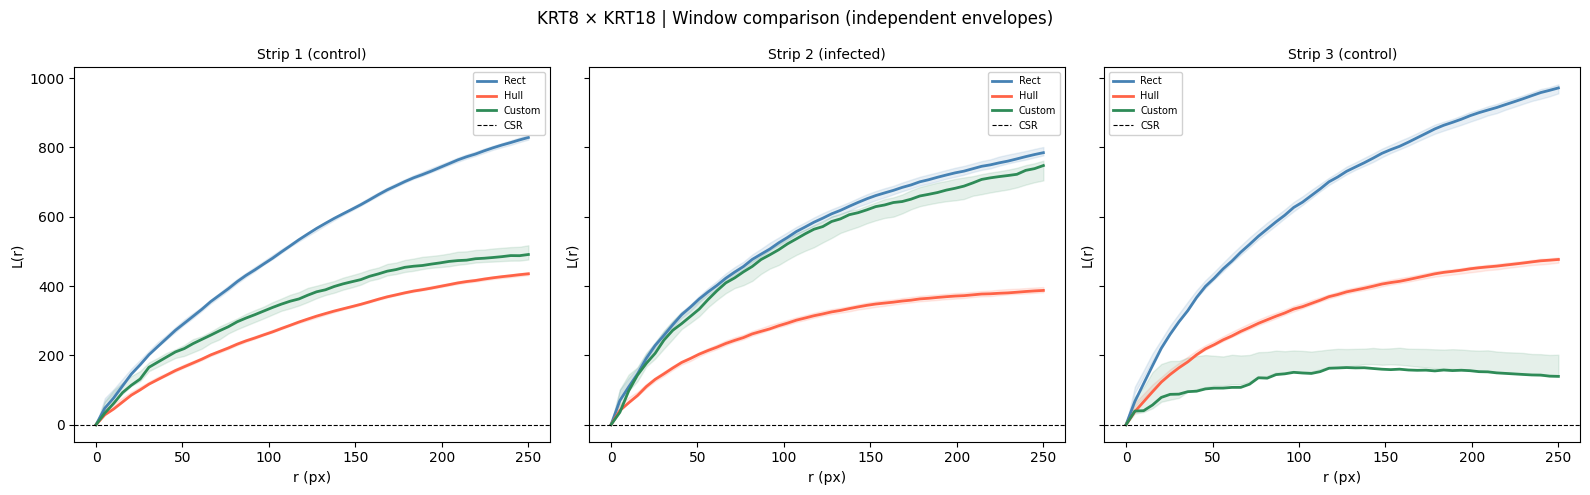

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, strip_name in zip(axes, STRIPS):
    strip_results = results_comparison_krt8[strip_name]

    # Reference envelope: hull (or the independent one per window type)
    hull_res = strip_results.get('hull')

    for wtype, (colour, ls, label) in WINDOW_STYLES.items():
        if wtype not in strip_results:
            continue
        res = strip_results[wtype]

        if INDEPENDENT_ENVELOPES:
            ax.fill_between(r_vals, res['l_lo'], res['l_hi'],
                            alpha=0.12, color=colour)
        elif wtype == 'hull' and hull_res is not None:
            ax.fill_between(r_vals, hull_res['l_lo'], hull_res['l_hi'],
                            alpha=0.18, color='grey', label='Hull envelope (shared)')

        ax.plot(r_vals, res['l_obs'],
                color=colour, lw=2, linestyle=ls, label=label)

    ax.axhline(0, color='black', lw=0.8, linestyle='--', label='CSR')
    ax.set_title(STRIP_LABELS[strip_name], fontsize=10)
    ax.set_xlabel('r (px)')
    ax.set_ylabel('L(r)')
    ax.legend(fontsize=7, framealpha=0.9)

env_note = 'independent envelopes' if INDEPENDENT_ENVELOPES else 'shared hull envelope'
fig.suptitle(f'KRT8 \u00d7 KRT18 | Window comparison ({env_note})', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/09c_KRT8_KRT18_window_comparison.png', dpi=150)
plt.show()

## Section 4: L(r) comparison â€” MALAT1 x KRT18 (negative control)

In [7]:
GENE_A = 'MALAT1'
GENE_B = 'KRT18'

results_comparison_malat1 = {strip: {} for strip in STRIPS}

for strip_name in STRIPS:
    strip_df = all_strips_clean[all_strips_clean['strip'] == strip_name]
    custom_path = CUSTOM_PATHS[strip_name]

    for wtype in ['rect', 'hull', 'custom']:
        if wtype == 'custom' and not os.path.exists(custom_path):
            continue

        print(f'\n{strip_name} | {GENE_A} \u00d7 {GENE_B} | window={wtype}')
        results_comparison_malat1[strip_name][wtype] = run_pair_analysis(
            strip_df, GENE_A, GENE_B, r_vals,
            window_type=wtype,
            custom_path=custom_path if wtype == 'custom' else None,
            n_sim=N_SIM, seed=SEED, strip_name=strip_name,
        )


strip_1 | MALAT1 × KRT18 | window=rect
  MALAT1: 30189 transcripts
  KRT18: 1811 transcripts
  Window: rect, narrowest dim = 7193 px
  R_MAX = 250 px
  Observed L(r) in 4.6s
    L(r=50): 297.98
    L(r=100): 479.26
    L(r=200): 738.63
  Envelope in 448.2s

strip_1 | MALAT1 × KRT18 | window=hull
  MALAT1: 30189 transcripts
  KRT18: 1811 transcripts
  Window: hull, area = 147772526 px²
  R_MAX = 250 px
  Observed L(r) in 35.1s
    L(r=50): 170.58
    L(r=100): 267.08
    L(r=200): 396.51
  Envelope in 11879.4s

strip_1 | MALAT1 × KRT18 | window=custom
  MALAT1: 30189 transcripts
  KRT18: 1811 transcripts
  Window: custom, area = 26320133 px²
  R_MAX = 250 px
  Observed L(r) in 110.7s
    L(r=50): 215.09
    L(r=100): 335.23
    L(r=200): 460.74
  Envelope in 4989.4s

strip_2 | MALAT1 × KRT18 | window=rect
  MALAT1: 17989 transcripts
  KRT18: 1088 transcripts
  Window: rect, narrowest dim = 6171 px
  R_MAX = 250 px
  Observed L(r) in 1.9s
    L(r=50): 355.30
    L(r=100): 538.70
    L(r

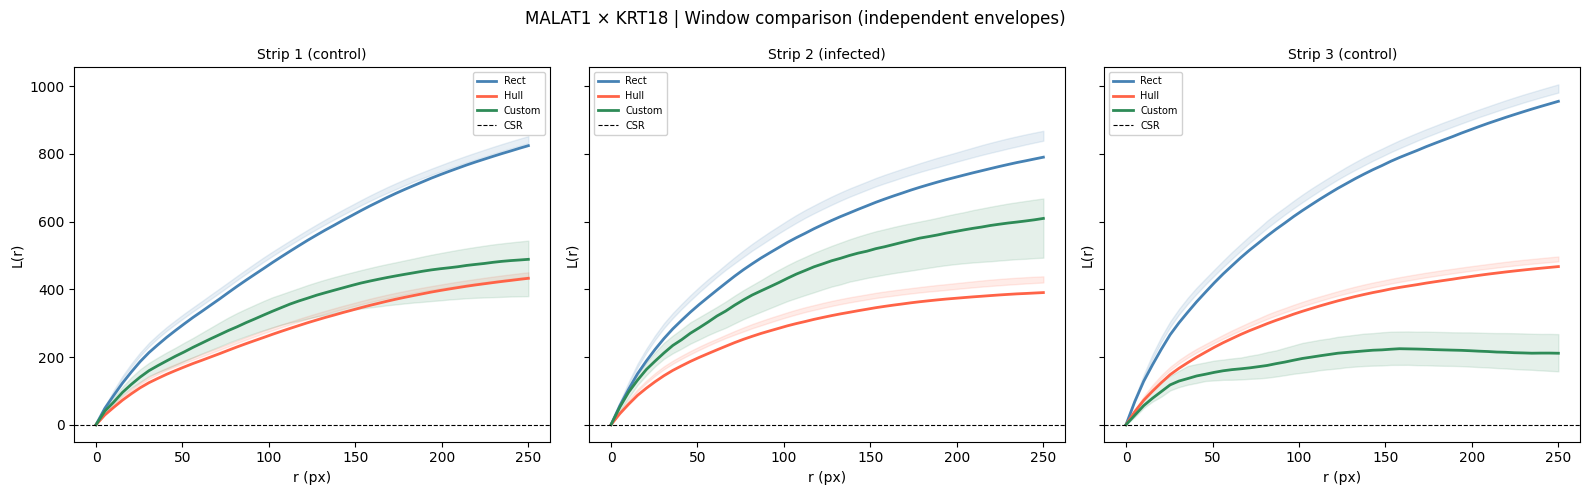

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, strip_name in zip(axes, STRIPS):
    strip_results = results_comparison_malat1[strip_name]
    hull_res = strip_results.get('hull')

    for wtype, (colour, ls, label) in WINDOW_STYLES.items():
        if wtype not in strip_results:
            continue
        res = strip_results[wtype]

        if INDEPENDENT_ENVELOPES:
            ax.fill_between(r_vals, res['l_lo'], res['l_hi'],
                            alpha=0.12, color=colour)
        elif wtype == 'hull' and hull_res is not None:
            ax.fill_between(r_vals, hull_res['l_lo'], hull_res['l_hi'],
                            alpha=0.18, color='grey', label='Hull envelope (shared)')

        ax.plot(r_vals, res['l_obs'],
                color=colour, lw=2, linestyle=ls, label=label)

    ax.axhline(0, color='black', lw=0.8, linestyle='--', label='CSR')
    ax.set_title(STRIP_LABELS[strip_name], fontsize=10)
    ax.set_xlabel('r (px)')
    ax.set_ylabel('L(r)')
    ax.legend(fontsize=7, framealpha=0.9)

env_note = 'independent envelopes' if INDEPENDENT_ENVELOPES else 'shared hull envelope'
fig.suptitle(f'MALAT1 \u00d7 KRT18 | Window comparison ({env_note})', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/09c_MALAT1_KRT18_window_comparison.png', dpi=150)
plt.show()